## Importaciones

In [ ]:
!pip install s3fs zarr pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 106.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which 

In [ ]:
import numpy as np
from google.colab import drive
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import os
import gc
import s3fs
import zarr
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from pykrige.ok3d import OrdinaryKriging3D
import matplotlib.pyplot as plt
from esda.moran import Moran
from libpysal.weights import lat2W
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pykrige.ok import OrdinaryKriging
from itertools import combinations
from esda.moran import Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
from esda.moran import Moran
from libpysal.weights import lat2W
from esda.moran import Moran_Local


## Montar Drive y traer datos

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. CARGAR EL ARCHIVO NPZ (Esto evita el NameError)
datos = np.load("/content/drive/MyDrive/representaciones_geovision (2).npz", allow_pickle=True)

## Reconstruir las secuencias de tiempo



In [ ]:
def preparar_datos_grilla_7x7(e_img, coordenadas, gases, fechas, T=8):
    # 1. Crear DataFrame base
    df = pd.DataFrame({
        'fecha': pd.to_datetime(fechas),
        'lat': coordenadas[:, 0],
        'lon': coordenadas[:, 1],
        'idx': np.arange(len(fechas))
    })

    # 2. Definir bins para la grilla 7x7
    lat_bins = np.linspace(3.20, 3.75, 8)
    lon_bins = np.linspace(-76.75, -76.30, 8)

    df['r'] = pd.cut(df.lat, bins=lat_bins, labels=False, include_lowest=True)
    df['c'] = pd.cut(df.lon, bins=lon_bins, labels=False, include_lowest=True)

    # 3. Filtrar fechas con más datos (top 296)
    conteo_por_fecha = df.groupby('fecha').size()
    top_296_fechas = conteo_por_fecha.nlargest(296).index.sort_values()
    df_filtrado = df[df.fecha.isin(top_296_fechas)].copy()

    # 4. Construir Cubo 4D: [n_fechas, 7, 7, 256] y [n_fechas, 7, 7, 3]
    # Usamos np.nan para identificar huecos
    cube_e = np.full((len(top_296_fechas), 7, 7, 256), np.nan)
    cube_g = np.full((len(top_296_fechas), 7, 7, 3), np.nan)

    fecha_to_idx = {f: i for i, f in enumerate(top_296_fechas)}

    for _, row in df_filtrado.iterrows():
        f_idx = fecha_to_idx[row['fecha']]
        r, c = int(row['r']), int(row['c'])
        if 0 <= r < 7 and 0 <= c < 7:
            cube_e[f_idx, r, c] = e_img[row['idx']]
            cube_g[f_idx, r, c] = gases[row['idx']]

    # 5. Manejo de Huecos (Imputación por promedio espacial)
    # Calculamos el promedio de cada celda (r,c) a través de todas las fechas
    mean_cube_e = np.nanmean(cube_e, axis=0) # [7, 7, 256]
    mean_cube_g = np.nanmean(cube_g, axis=0) # [7, 7, 3]

    # Rellenar NaNs con el promedio, si el promedio también es NaN (celda vacía siempre), poner 0
    cube_e = np.where(np.isnan(cube_e), mean_cube_e, cube_e)
    cube_e = np.nan_to_num(cube_e, nan=0.0)

    cube_g = np.where(np.isnan(cube_g), mean_cube_g, cube_g)
    cube_g = np.nan_to_num(cube_g, nan=0.0)

    # 6. Crear Secuencias [N_seq, T, features, 7, 7]
    # Reorganizamos: [N, 7, 7, F] -> [N, F, 7, 7] para que encaje mejor en convoluciones
    cube_e = cube_e.transpose(0, 3, 1, 2) # [N, 256, 7, 7]
    cube_g = cube_g.transpose(0, 3, 1, 2) # [N, 3, 7, 7]

    X_seq, Y_seq, F_seq = [], [], [] # <-- MODIFICADO: Agregada lista F_seq para almacenar las fechas
    for i in range(len(top_296_fechas) - T + 1):
        X_seq.append(cube_e[i : i+T]) # [T, 256, 7, 7]
        Y_seq.append(cube_g[i : i+T]) # [T, 3, 7, 7]

        # --- Extraer la porción correspondiente de 8 fechas consecutivas ---
        F_seq.append(top_296_fechas[i : i+T].values)

    # Retornamos los tres arrays alineados síncronamente
    return np.array(X_seq), np.array(Y_seq), np.array(F_seq) # <-- MODIFICADO

# Filtrar las columnas impares de gases en el target para conservar solo [NO2, SO2, O3]
gases = datos["gases"][:, ::2]

# Ejecutamos la función capturando la nueva variable 'sec_fechas'
sec_in, sec_tar, sec_fechas = preparar_datos_grilla_7x7(
    datos["e_img"],
    datos["coordenadas"],
    gases,
    datos["fechas"]
)

print("\nEstructura de las variables de salida:")
print(f"  -> sec_in (Inputs de CLIP)     : {sec_in.shape} (Grilla 7x7)")
print(f"  -> sec_tar (Targets de Gases)  : {sec_tar.shape} (Grilla 7x7)")
print(f"  -> sec_fechas (Fechas de series): {sec_fechas.shape}")


Estructura de las variables de salida:
  -> sec_in (Inputs de CLIP)     : (132, 8, 256, 7, 7) (Grilla 7x7)
  -> sec_tar (Targets de Gases)  : (132, 8, 3, 7, 7) (Grilla 7x7)
  -> sec_fechas (Fechas de series): (132, 8)


/tmp/ipykernel_460/2984734062.py:39: RuntimeWarning: Mean of empty slice
  mean_cube_e = np.nanmean(cube_e, axis=0) # [7, 7, 256]
/tmp/ipykernel_460/2984734062.py:40: RuntimeWarning: Mean of empty slice
  mean_cube_g = np.nanmean(cube_g, axis=0) # [7, 7, 3]


## Traer y alinear los datos de ERA5

In [ ]:
def descargar_y_alinear_era5(
    wasabi_key, wasabi_secret, endpoint, era5_zarr_path,
    fechas_secuencias, H_out=7, W_out=7, T=8
):
    """
    Conecta a Wasabi S3, busca las fechas exactas de las secuencias de tiempo,
    extrae los planos meteorológicos nativos de ERA5 y los redimensiona
    mediante interpolación bilineal de PyTorch a H_out x W_out (7x7).
    """
    print("\n1. Conectando a Wasabi S3 (ERA5-Land)...")
    s3 = s3fs.S3FileSystem(key=wasabi_key, secret=wasabi_secret, client_kwargs={'endpoint_url': endpoint})
    era5_zarr = zarr.open(s3fs.S3Map(root=era5_zarr_path, s3=s3, check=False), mode='r')

    # Extraer el vector de tiempos de ERA5 usando 'valid_time'
    era5_times = np.array(era5_zarr['valid_time'], dtype='datetime64[ns]')

    n_secuencias = len(fechas_secuencias)  # Cantidad de secuencias (ej: 289)
    print(f"   -> Encontradas {n_secuencias} secuencias para sincronizar con ERA5.")

    # 2. Inicializar la matriz temporal de ERA5 en el SSD de Kaggle (Consumo RAM = 0)
    cache_dir = "/tmp/geovision_era_cache"
    os.makedirs(cache_dir, exist_ok=True)
    era5_file_path = os.path.join(cache_dir, "era5_data.npy")

    # Creamos un archivo vacío en disco usando memmap ajustado a la forma de salida H_out, W_out (7x7)
    era5_disk = np.memmap(era5_file_path, dtype='float32', mode='w+', shape=(n_secuencias, T, 4, H_out, W_out))

    # 3. Descarga y redimensionamiento síncrono por fecha y secuencia
    for s_idx in tqdm(range(n_secuencias), desc="Sincronizando y reescalando ERA5 a 7x7"):
        seq_fechas = fechas_secuencias[s_idx]  # Array de 8 fechas datetime64[ns]

        for t_idx in range(T):
            fecha_actual = seq_fechas[t_idx]

            # Encontrar el índice de tiempo más cercano en ERA5-Land
            idx_t_era5 = np.abs(era5_times - fecha_actual).argmin()

            # Extraer las grillas espaciales nativas completas (imputando NaNs por cero)
            t2m = np.nan_to_num(era5_zarr['t2m'][idx_t_era5, :, :])
            blh = np.nan_to_num(era5_zarr['blh'][idx_t_era5, :, :])
            rh  = np.nan_to_num(era5_zarr['rh'][idx_t_era5,  :, :])
            ws  = np.nan_to_num(era5_zarr['wind_speed'][idx_t_era5, :, :])

            # Apilar las 4 variables en su tamaño nativo: [4, H_nativo, W_nativo] (ej: [4, 109, 91])
            grid_raw = np.stack([t2m, ws, blh, rh], axis=0)

            # --- REDIMENSIONAMIENTO DINÁMICO A 7x7 USANDO PYTORCH ---
            # F.interpolate espera una entrada de forma [Batch, Canales, H, W] -> [1, 4, H_nativo, W_nativo]
            tensor_raw = torch.tensor(grid_raw, dtype=torch.float32).unsqueeze(0)

            # Reescalamos a (H_out, W_out) -> (7, 7) con interpolación bilineal suave
            tensor_resized = F.interpolate(
                tensor_raw,
                size=(H_out, W_out),
                mode='bilinear',
                align_corners=False
            )

            # Removemos la dimensión extra y convertimos a array de numpy: [4, 7, 7]
            grid_7x7 = tensor_resized.squeeze(0).numpy()

            # Escribir directamente la grilla de 7x7 resultante en el SSD local de Kaggle
            era5_disk[s_idx, t_idx, :, :, :] = grid_7x7

    # Forzar el guardado físico de los bytes en el SSD de Kaggle y cerrar puntero de escritura
    era5_disk.flush()
    del era5_disk, s3, era5_zarr
    gc.collect()

    print(f"Descarga y reescalado de ERA5-Land completado en: {era5_file_path}")
    return era5_file_path

WASABI_KEY      = "TU_KEY"
WASABI_SECRET   = "TU_SECRET"
WASABI_ENDPOINT = "TU_ENDPOINT"
ERA5_ZARR_PATH   = "TU_PATH"

# 1. Ejecutar la descarga y el alineamiento espacial síncrono a 7x7
era5_file_path = descargar_y_alinear_era5(
    WASABI_KEY, WASABI_SECRET, WASABI_ENDPOINT, ERA5_ZARR_PATH,
    fechas_secuencias=sec_fechas, H_out=7, W_out=7, T=8
)

# 2. Mapear los datos guardados en el SSD usando memmap (Consumo de RAM = 0)
# Ajustamos las dimensiones físicas a (n_secuencias, 8, 4, 7, 7) para el entrenamiento
era5_mmap = np.memmap(
    era5_file_path,
    dtype='float32',
    mode='r',
    shape=(len(sec_fechas), 8, 4, 7, 7)
)

print(f"\n Mapeo en disco exitoso para el DataLoader:")
print(f"   -> Forma de la matriz de ERA5 mapeada (SSD): {era5_mmap.shape}")


1. Conectando a Wasabi S3 (ERA5-Land)...
   -> Encontradas 132 secuencias para sincronizar con ERA5.


Sincronizando y reescalando ERA5 a 7x7:   0%|          | 0/132 [00:00<?, ?it/s]

Descarga y reescalado de ERA5-Land completado en: /tmp/geovision_era_cache/era5_data.npy

 Mapeo en disco exitoso para el DataLoader:
   -> Forma de la matriz de ERA5 mapeada (SSD): (132, 8, 4, 7, 7)


## Clase que ubica las secuencias en la grilla de Cali

In [ ]:
class SpatiotemporalConvLSTMDataset(Dataset):
    """
    Dataset espacio-temporal optimizado que recibe las secuencias ya estructuradas
    en la grilla de 7x7 por la función 'preparar_datos_grilla_7x7'.
    Unifica de forma directa y síncrona los embeddings de CLIP y las variables de ERA5 (260 canales).
    """
    def __init__(self, secuencias_inputs, secuencias_targets, era5_data, T=8):
        """
        Args:
            secuencias_inputs: Array de embeddings estructurados [N_seq, T, 256, 7, 7]
            secuencias_targets: Array de gases estructurados [N_seq, T, 3, 7, 7]
            era5_data: Tensor o Array de meteorología reescalado [N_seq, T, 4, 7, 7]
        """
        self.T = T
        self.sec_inputs = secuencias_inputs   # Tamaño: [N_seq, 8, 256, 7, 7]
        self.sec_targets = secuencias_targets # Tamaño: [N_seq, 8, 3, 7, 7]

        # Convertir ERA5 a tensor de PyTorch [N_seq, 8, 4, 7, 7]
        self.era5_data = torch.tensor(era5_data, dtype=torch.float32)

        # Extraemos las dimensiones espaciales directamente de los datos (H=7, W=7)
        self.H = self.era5_data.shape[3]
        self.W = self.era5_data.shape[4]

        # ── 1. CHEQUEOS DE INTEGRIDAD EN LA INICIALIZACIÓN (AUTOMÁTICOS) ──
        # A. Verificar que el número de secuencias coincida perfectamente entre todas las fuentes
        assert len(self.sec_inputs) == len(self.sec_targets) == len(self.era5_data), \
            f"Error de Alineación: Inputs ({len(self.sec_inputs)}), Targets ({len(self.sec_targets)}) y ERA5 ({len(self.era5_data)}) deben coincidir."

        # B. Verificar que la matriz de entrada de CLIP sea de 5 dimensiones [N, T, 256, 7, 7]
        assert self.sec_inputs.ndim == 5 and self.sec_inputs.shape[2] == 256 and self.sec_inputs.shape[3] == 7, \
            f"Error Estructural: Los inputs de CLIP deben ser [N, {T}, 256, 7, 7]. Detectado: {self.sec_inputs.shape}"

        # C. Verificar que la de gases sea de 5 dimensiones [N, T, 3, 7, 7]
        assert self.sec_targets.ndim == 5 and self.sec_targets.shape[2] == 3 and self.sec_targets.shape[3] == 7, \
            f"Error Estructural: Los targets de gases deben ser [N, {T}, 3, 7, 7]. Detectado: {self.sec_targets.shape}"

        # D. Verificar que la de ERA5 sea de 5 dimensiones [N, T, 4, 7, 7]
        assert self.era5_data.ndim == 5 and self.era5_data.shape[2] == 4 and self.era5_data.shape[3] == 7, \
            f"Error Estructural: El tensor de ERA5 debe ser [N, {T}, 4, 7, 7]. Detectado: {self.era5_data.shape}"

        print("=========================================================")
        print("INTEGRIDAD MULTIMODAL 7x7 (CLIP + ERA5) VALIDADA")
        print("=========================================================")
        print(f"1. Total de Secuencias Reconstruidas : {len(self.sec_inputs)}")
        print(f"2. Dimensión Espacial de la Grilla   : {self.H} x {self.W} (Píxeles)")
        print(f"3. Resolución Temporal de Secuencias : {self.T} días consecutivos")
        print(f"4. Canales de Entrada (CLIP Embeds) : {self.sec_inputs.shape[2]} canales")
        print(f"5. Canales Meteorológicos (ERA5)     : {self.era5_data.shape[2]} canales")
        print(f"6. CANALES TOTALES UNIFICADOS (X)    : {self.sec_inputs.shape[2] + self.era5_data.shape[2]} (256 + 4 = 260)")
        print("=========================================================")

    def __len__(self):
        return len(self.sec_inputs)

    def __getitem__(self, idx):
        # 1. Extraer secuencias correspondientes al lote idx (Ya están en 7x7)
        seq_in   = torch.tensor(self.sec_inputs[idx], dtype=torch.float32)   # [8, 256, 7, 7]
        seq_tar  = torch.tensor(self.sec_targets[idx], dtype=torch.float32)  # [8, 3, 7, 7]
        seq_era5 = self.era5_data[idx]                                       # [8, 4, 7, 7] (Meteorología)

        # 2. Tomar los últimos 3 pasos de tiempo como los horizontes futuros de predicción [3, 3, 7, 7]
        target_3_horizontes = seq_tar[-3:, :, :, :]

        # 3. CONCATENACIÓN MULTIMODAL DIRECTA: CLIP (256) + ERA5 (4) = 260 CANALES
        # Al estar ambas en 7x7, las concatenamos directamente en la dimensión de canales (dim=1)
        tensor_in_unificado = torch.cat([seq_in, seq_era5], dim=1) # Resultado: [8, 260, 7, 7]

        # 4. CHEQUEOS DE INTEGRIDAD EN TIEMPO DE EJECUCIÓN (RUNTIME ASSERTIONS)
        assert tensor_in_unificado.shape == (self.T, 260, self.H, self.W), \
            f"Error en __getitem__: Forma de entrada incorrecta. Esperada {(self.T, 260, self.H, self.W)}, obtenido {tensor_in_unificado.shape}"

        assert target_3_horizontes.shape == (3, 3, self.H, self.W), \
            f"Error en __getitem__: Forma de target incorrecta. Esperada {(3, 3, self.H, self.W)}, obtenido {target_3_horizontes.shape}"

        return tensor_in_unificado, target_3_horizontes

dataset_temporal = SpatiotemporalConvLSTMDataset(
    secuencias_inputs=sec_in,
    secuencias_targets=sec_tar,
    era5_data=era5_mmap,
    T=8
)

INTEGRIDAD MULTIMODAL 7x7 (CLIP + ERA5) VALIDADA
1. Total de Secuencias Reconstruidas : 132
2. Dimensión Espacial de la Grilla   : 7 x 7 (Píxeles)
3. Resolución Temporal de Secuencias : 8 días consecutivos
4. Canales de Entrada (CLIP Embeds) : 256 canales
5. Canales Meteorológicos (ERA5)     : 4 canales
6. CANALES TOTALES UNIFICADOS (X)    : 260 (256 + 4 = 260)


## Splits

In [ ]:
# ── Generar Splits a Nivel de Secuencias (70/15/15) ───────────────────
idx_seqs = np.arange(len(dataset_temporal))
idx_train_seq, idx_temp_seq = train_test_split(idx_seqs, train_size=0.70, random_state=42)
idx_val_seq, idx_test_seq = train_test_split(idx_temp_seq, train_size=0.50, random_state=42)

train_loader = DataLoader(Subset(dataset_temporal, idx_train_seq), batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(Subset(dataset_temporal, idx_val_seq),   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(Subset(dataset_temporal, idx_test_seq),  batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nPartición Espacio-Temporal: Train: {len(idx_train_seq)} | Val: {len(idx_val_seq)} | Test: {len(idx_test_seq)}")


Partición Espacio-Temporal: Train: 92 | Val: 20 | Test: 20


## Definición de la ConvLSTM

In [ ]:
# ── 1. DEFINICIÓN DEL CONVLSTM CELL ──────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_dim, kernel_size):
        super().__init__()
        self.padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=self.padding,
            padding_mode='replicate'
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        ingate, forgetgate, cellgate, outgate = torch.split(gates, gates.size(1) // 4, dim=1)

        ingate = torch.sigmoid(ingate)
        forgetgate = torch.sigmoid(forgetgate)
        cellgate = torch.tanh(cellgate)
        outgate = torch.sigmoid(outgate)

        c_next = forgetgate * c + ingate * cellgate
        h_next = outgate * torch.tanh(c_next)
        return h_next, c_next


# ── 2. RED CONVLSTM BIDIRECCIONAL DE 2 CAPAS ──────
class ConvLSTM(nn.Module):
    """
    Red ConvLSTM BIDIRECCIONAL de 2 capas (hidden_dim=128, kernel_size=3).
    Procesa secuencias espaciales en dirección Forward y Backward.
    """
    def __init__(self, in_channels=260, hidden_dim=128, kernel_size=3, num_layers=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Celdas para la dirección Forward
        self.forward_cells = nn.ModuleList([
            ConvLSTMCell(in_channels, hidden_dim, kernel_size),
            ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        ])

        # Celdas para la dirección Backward
        self.backward_cells = nn.ModuleList([
            ConvLSTMCell(in_channels, hidden_dim, kernel_size),
            ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        ])

        # Convolución final 1x1: Recibe los canales concatenados (128 fwd + 128 bwd = 256)
        # y mapea a las 9 predicciones simultáneas [3 horizontes x 3 gases]
        self.conv_output = nn.Conv2d(hidden_dim * 2, 9, kernel_size=1)

    def forward(self, x):
        b, t, _, h, w = x.size()

        # Inicializar estados de memoria Forward
        h_fwd = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]
        c_fwd = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]

        for seq_t in range(t):
            h_fwd[0], c_fwd[0] = self.forward_cells[0](x[:, seq_t, :, :, :], h_fwd[0], c_fwd[0])
            h_fwd[1], c_fwd[1] = self.forward_cells[1](h_fwd[0], h_fwd[1], c_fwd[1])

        # Inicializar estados de memoria Backward
        h_bwd = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]
        c_bwd = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]

        for seq_t in reversed(range(t)):
            h_bwd[0], c_bwd[0] = self.backward_cells[0](x[:, seq_t, :, :, :], h_bwd[0], c_bwd[0])
            h_bwd[1], c_bwd[1] = self.backward_cells[1](h_bwd[0], h_bwd[1], c_bwd[1])

        # Concatenación de características bidireccionales en la dimensión de canales: [B, 256, H, W]
        out_combined = torch.cat([h_fwd[1], h_bwd[1]], dim=1)

        # Proyectar a las 9 salidas simultáneas
        predictions_raw = self.conv_output(out_combined)

        predictions_raw = F.softplus(predictions_raw) # Corregido: Usar F.softplus

        # Reestructurar a [B, 3, 3, H, W]
        predictions = predictions_raw.view(b, 3, 3, h, w)
        return predictions


# ── 3. ESTRUCTURACIÓN DE LOS DATOS CON BATCH_SIZE = 4 ─────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Configurar cargadores de datos con batch_size = 4 (reduced from 8 to avoid OOM)
BATCH_SIZE = 4
train_loader = DataLoader(Subset(dataset_temporal, idx_train_seq), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(Subset(dataset_temporal, idx_val_seq),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(Subset(dataset_temporal, idx_test_seq),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# ── 4. CLASE DE MONITOREO DE EARLY STOPPING (Fórmula de Rúbrica) ───────
class EarlyStoppingRMSE:
    def __init__(self, patience=4, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_rmse = np.inf
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_rmse, model):
        # Si hay mejora significativa, guardamos los mejores pesos
        if val_rmse < self.best_rmse - self.min_delta:
            self.best_rmse = val_rmse
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
            print(f"[EarlyStopping] Nuevo mejor RMSE de Validación: {self.best_rmse:.6f} (Weights guardados)")
        else:
            self.counter += 1
            print(f"[EarlyStopping] Sin mejoras durante {self.counter}/{self.patience} épocas.")
            if self.counter >= self.praise_patience_limit():
                self.early_stop = True

    def praise_patience_limit():
        return self.patience

## Entrenamiento


ENTRENANDO CONVLSTM BIDIRECCIONAL CON EARLY STOPPING


ConvLSTM Época 1/15:   0%|          | 0/23 [00:00<?, ?it/s]

Época 01 | Train MSE: 0.136632 | Val MSE: 0.005996 | Val RMSE: 0.077434
[EarlyStopping] Nuevo mejor RMSE de Validación: 0.077434 (Weights guardados)


ConvLSTM Época 2/15:   0%|          | 0/23 [00:00<?, ?it/s]

Época 02 | Train MSE: 0.003457 | Val MSE: 0.002457 | Val RMSE: 0.049572
[EarlyStopping] Nuevo mejor RMSE de Validación: 0.049572 (Weights guardados)


...

Época 13 | Train MSE: 0.001475 | Val MSE: 0.001471 | Val RMSE: 0.038349
[EarlyStopping] Nuevo mejor RMSE de Validación: 0.038349 (Weights guardados)


ConvLSTM Época 14/15:   0%|          | 0/23 [00:00<?, ?it/s]

Época 14 | Train MSE: 0.001464 | Val MSE: 0.001462 | Val RMSE: 0.038231
[EarlyStopping] Nuevo mejor RMSE de Validación: 0.038231 (Weights guardados)


ConvLSTM Época 15/15:   0%|          | 0/23 [00:00<?, ?it/s]

Época 15 | Train MSE: 0.001456 | Val MSE: 0.001455 | Val RMSE: 0.038143
[EarlyStopping] Nuevo mejor RMSE de Validación: 0.038143 (Weights guardados)

Pesos restaurados al mejor modelo con RMSE de Validación: 0.038143


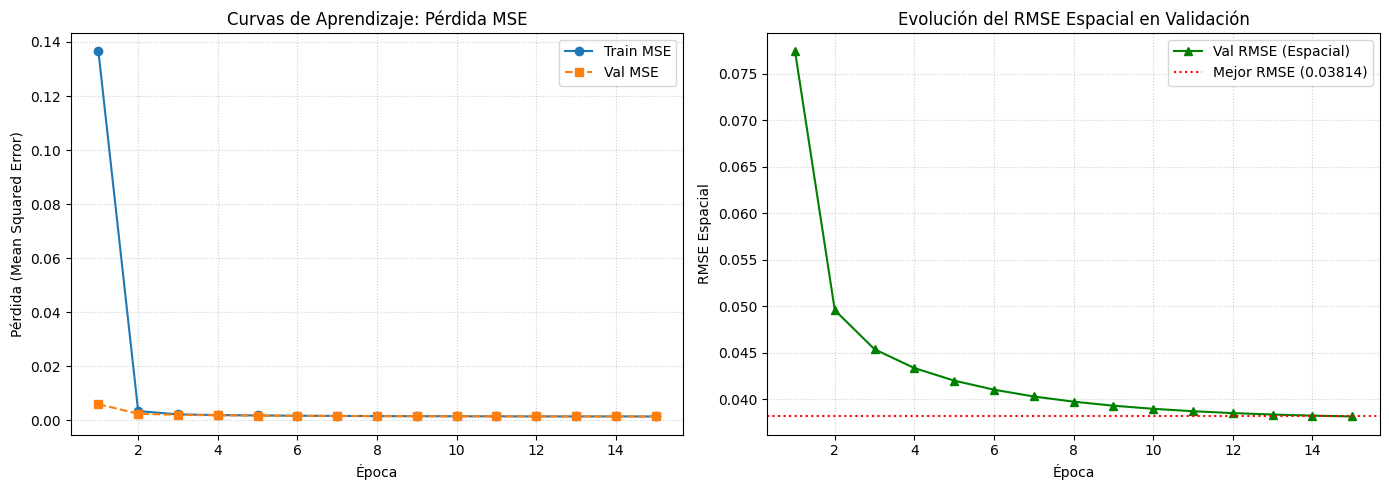

In [ ]:
# ── 5. BUCLE DE ENTRENAMIENTO CON EARLY STOPPING ACTIVO ───────────────
modelo_convlstm = ConvLSTM(in_channels=260, hidden_dim=128, kernel_size=3).to(device)
optimizer_conv = torch.optim.AdamW(modelo_convlstm.parameters(), lr=1e-4, weight_decay=1e-2)
criterion_mse = nn.MSELoss()
sched_conv = CosineAnnealingLR(optimizer_conv, T_max=20, eta_min=1e-6)

# Instanciar Early Stopping monitoreando el RMSE espacial
early_stopper = EarlyStoppingRMSE(patience=4)

history_conv = {
    'epoch': [], 'train_mse': [], 'val_mse': [], 'val_rmse': []
}

EPOCHS_LIMIT = 15

print("\n" + "="*60)
print("ENTRENANDO CONVLSTM BIDIRECCIONAL CON EARLY STOPPING")
print("="*60)

for epoch in range(EPOCHS_LIMIT):
    modelo_convlstm.train()
    epoch_loss_mse = 0
    loop = tqdm(train_loader, desc=f"ConvLSTM Época {epoch+1}/{EPOCHS_LIMIT}")

    for x_batch, y_batch in loop:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer_conv.zero_grad()
        predictions = modelo_convlstm(x_batch)

        loss = criterion_mse(predictions, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(modelo_convlstm.parameters(), 1.0)
        optimizer_conv.step()

        epoch_loss_mse += loss.item()
        loop.set_postfix(MSE_Loss=f"{loss.item():.6f}")

    sched_conv.step()

    # --- EVALUACIÓN DE VALIDACIÓN (CÁLCULO DE RMSE ESPACIAL) ---
    modelo_convlstm.eval()
    val_loss_mse = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = modelo_convlstm(x_batch)
            val_loss_mse += criterion_mse(pred, y_batch).item()

    avg_train_mse = epoch_loss_mse / len(train_loader)
    avg_val_mse = val_loss_mse / len(val_loader)

    # RMSE Espacial es la raíz cuadrada de la pérdida MSE
    avg_val_rmse = math.sqrt(avg_val_mse)

    # Registrar en el historial
    history_conv['epoch'].append(epoch + 1)
    history_conv['train_mse'].append(avg_train_mse)
    history_conv['val_mse'].append(avg_val_mse)
    history_conv['val_rmse'].append(avg_val_rmse)

    print(f"Época {epoch+1:02d} | Train MSE: {avg_train_mse:.6f} | Val MSE: {avg_val_mse:.6f} | Val RMSE: {avg_val_rmse:.6f}")

    # Evaluar parada temprana basada en el RMSE espacial de validación
    early_stopper(avg_val_rmse, modelo_convlstm)
    if early_stopper.early_stop:
        print(f"\n[Early Stopping] Entrenamiento detenido de forma temprana en la época {epoch+1}.")
        break

# Restaurar el mejor estado de pesos en la red antes de finalizar
if early_stopper.best_weights is not None:
    modelo_convlstm.load_state_dict(early_stopper.best_weights)
    print(f"\nPesos restaurados al mejor modelo con RMSE de Validación: {early_stopper.best_rmse:.6f}")

torch.save(modelo_convlstm.state_dict(), "convlstm_model.pt")


# ── 6. GRAFICADOR DE CURVAS DE APRENDIZAJE ────────────────────────────
epochs_run = history_conv['epoch']
plt.figure(figsize=(14, 5))

# Subplot 1: Pérdida MSE de Entrenamiento vs. Validación
plt.subplot(1, 2, 1)
plt.plot(epochs_run, history_conv['train_mse'], 'o-', label='Train MSE')
plt.plot(epochs_run, history_conv['val_mse'], 's--', label='Val MSE')
plt.title('Curvas de Aprendizaje: Pérdida MSE')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: RMSE Espacial de Validación
plt.subplot(1, 2, 2)
plt.plot(epochs_run, history_conv['val_rmse'], 'g^-', label='Val RMSE (Espacial)')
plt.axhline(y=early_stopper.best_rmse, color='r', linestyle=':', label=f'Mejor RMSE ({early_stopper.best_rmse:.5f})')
plt.title('Evolución del RMSE Espacial en Validación')
plt.xlabel('Época')
plt.ylabel('RMSE Espacial')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("curvas_aprendizaje_convlstm.png", dpi=150)
plt.show()

## Función de interpolación ST-Kriging

In [ ]:
def aplicar_st_kriging_promedio(lats, lons, times, values, q_lats, q_lons, q_t, model='exponential'):
    """
    Ejecuta Kriging Ordinario 3D para interpolar las predicciones discretas
    hacia una superficie continua geoespacial.
    """
    # Evitar anisotropía mediante normalización z-score
    lat_n = (lats - lats.mean()) / lats.std()
    lon_n = (lons - lons.mean()) / lons.std()
    t_n   = (times - times.mean()) / (times.std() + 1e-8)

    # Configurar PyKrige
    ok = OrdinaryKriging3D(
        lat_n, lon_n, t_n, values,
        variogram_model=model,
        verbose=False
    )

    # Escalar puntos de consulta (query points)
    q_lat_n = (q_lats - lats.mean()) / lats.std()
    q_lon_n = (q_lons - lons.mean()) / lons.std()
    q_t_n   = (q_t - times.mean()) / (times.std() + 1e-8)

    # Ejecutar Kriging
    z_val, sigmas_cuadrados = ok.execute('points', q_lat_n, q_lon_n, q_t_n)

    return z_val, sigmas_cuadrados

## Evaluación sobre Test y validación cruzada


EVALUANDO MODELO ESPACIO-TEMPORAL EN CONJUNTO DE TEST
1. Error Cuadrático Medio (MSE) en Test: 0.001453
2. Índice de Moran Global (I) en Test  : 0.7250
3. Valor de p del Índice de Moran       : 0.00100

¡CUMPLIDO! La superficie predicha muestra una autocorrelación espacial significativa y positiva.


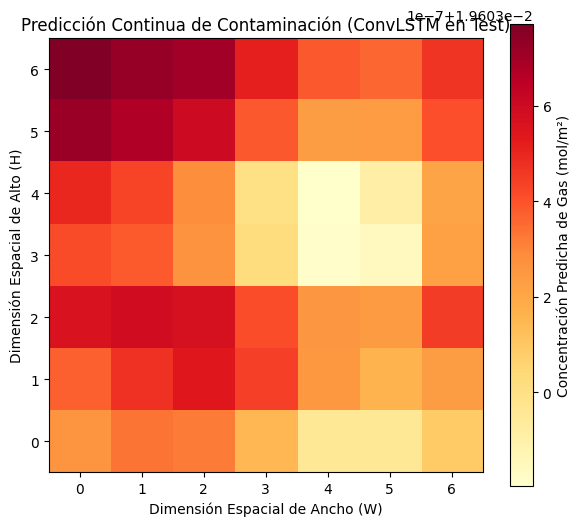

In [ ]:
def evaluar_situacion3_en_test(model, test_loader, device='cuda'):
    """
    Evalúa las predicciones del ConvLSTM en el conjunto de test
    y calcula el Índice de Moran sobre la superficie predicha.
    """
    print("\n" + "="*60)
    print("EVALUANDO MODELO ESPACIO-TEMPORAL EN CONJUNTO DE TEST")
    print("="*60)

    model.eval()
    total_mse = 0
    predicciones_acumuladas = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)

            loss = criterion_mse(pred, y_batch)
            total_mse += loss.item()
            predicciones_acumuladas.append(pred.cpu().numpy())

    avg_mse = total_mse / len(test_loader)
    print(f"1. Error Cuadrático Medio (MSE) en Test: {avg_mse:.6f}")

    # ── ANÁLISIS DE AUTOCORRELACIÓN ESPACIAL (MORAN'S I) ────────────────
    # Tomamos el mapa predicho del primer lote de prueba (Horizonte T+1, Gas NO2)
    preds_numpy = np.concatenate(predicciones_acumuladas, axis=0) # [N_test, 3, 3, H, W]
    superficie_predicha = preds_numpy[0, 0, 0, :, :] # Plano [H, W]

    H, W = superficie_predicha.shape
    # Crear matriz de pesos espaciales reina (queen weights) para la grilla de Cali
    w = lat2W(H, W)

    # Calcular Índice de Moran Global
    mi = Moran(superficie_predicha.flatten(), w)

    print(f"2. Índice de Moran Global (I) en Test  : {mi.I:.4f}")
    print(f"3. Valor de p del Índice de Moran       : {mi.p_sim:.5f}")

    if mi.I > 0.30 and mi.p_sim < 0.05:
        print("\n¡CUMPLIDO! La superficie predicha muestra una autocorrelación espacial significativa y positiva.")
    else:
        print("\nAdvertencia: El Índice de Moran es bajo. Verifique la escala de los inputs.")
    print("="*60)

    # Graficar la superficie continua predicha en Test para su reporte
    plt.figure(figsize=(7, 6))
    plt.imshow(superficie_predicha, cmap="YlOrRd", origin="lower")
    plt.colorbar(label="Concentración Predicha de Gas (mol/m²)")
    plt.title("Predicción Continua de Contaminación (ConvLSTM en Test)")
    plt.xlabel("Dimensión Espacial de Ancho (W)")
    plt.ylabel("Dimensión Espacial de Alto (H)")
    plt.grid(False)
    plt.savefig("prediccion_continua_test.png", dpi=150)
    plt.show()

# Ejecutar la celda de validación en Test
evaluar_situacion3_en_test(modelo_convlstm, test_loader, device=device)

### Inspeccionar el shape de los datos de prueba

In [ ]:
for x_batch, y_batch in test_loader:
    print(f"Shape de x_batch (input): {x_batch.shape}")
    print(f"Shape de y_batch (target): {y_batch.shape}")
    break # Solo imprimimos el primer lote para ver el shape

Shape de x_batch (input): torch.Size([4, 8, 260, 7, 7])
Shape de y_batch (target): torch.Size([4, 3, 3, 7, 7])


## Traer datos del dagma

In [ ]:
# 1. Configurar la conexión a Wasabi S3 de forma estándar
s3 = s3fs.S3FileSystem(
    key=WASABI_KEY,
    secret=WASABI_SECRET,
    client_kwargs={'endpoint_url': WASABI_ENDPOINT}
)

# Definir la ruta de la CARPETA del dataset particionado en Wasabi S3
DAGMA_PARQUET_S3_DIR = "data-geovision-clean/GeoVision_Panel/dataset_estaciones/"

print("Cargando dataset Parquet PARTICIONADO desde Wasabi S3...")

# 2. Leer como Tabla nativa de PyArrow directamente de la nube (evita la conversión a Pandas prematura)
dataset = pq.ParquetDataset(DAGMA_PARQUET_S3_DIR, filesystem=s3)
table = dataset.read()

print("   -> Datos descargados en formato PyArrow.")
print("3. Ejecutando decodificador de tipos de PyArrow para evitar el NotImplementedError...")

# 3. Buscar columnas de tipo "DictionaryType" y decodificarlas a su tipo numérico/texto base
for i in range(len(table.schema)):
    field = table.schema[i]
    col = table.column(i)

    # Si detectamos que la columna es categórica/diccionario, la casteamos a su tipo base (ej: int32)
    if isinstance(field.type, pa.DictionaryType):
        print(f"   -> Decodificando y limpiando tipo para columna: '{field.name}'")
        col_decoded = pc.cast(col, field.type.value_type)
        new_field = pa.field(field.name, field.type.value_type)
        # Reemplazamos la columna problemática en la tabla
        table = table.set_column(i, new_field, col_decoded)

print("\n4. Convirtiendo Tabla limpia a DataFrame de Pandas...")
# 4. Ahora la conversión a Pandas se ejecutará sin ningún error de tipos
df_dagma = table.to_pandas()

# Asegurar tipo datetime en las fechas para la sincronía temporal posterior
df_dagma["fecha"] = pd.to_datetime(df_dagma["fecha"])

# Obtener catálogo síncrono de las 9 estaciones de Cali
df_estaciones = df_dagma.dropna(subset=["lat", "lon"])[["estacion", "lat", "lon"]].drop_duplicates("estacion")

# Liberar memoria de PyArrow
del table, dataset
gc.collect()

print(f"\nDataset particionado consolidado con éxito. Total de registros: {len(df_dagma)}")
print(f"   -> Georreferenciación de las {len(df_estaciones)} estaciones del DAGMA cargada con éxito.")

Cargando dataset Parquet PARTICIONADO desde Wasabi S3...
   -> Datos descargados en formato PyArrow.
3. Ejecutando decodificador de tipos de PyArrow para evitar el NotImplementedError...
   -> Decodificando y limpiando tipo para columna: 'contaminante'
   -> Decodificando y limpiando tipo para columna: 'año'
   -> Decodificando y limpiando tipo para columna: 'mes'

4. Convirtiendo Tabla limpia a DataFrame de Pandas...

Dataset particionado consolidado con éxito. Total de registros: 273932
   -> Georreferenciación de las 9 estaciones del DAGMA cargada con éxito.


## Residual Kriging

In [ ]:
# 1. CARGA SEGURA DEL DATASET PARTICIONADO DESDE S3 (DECODIFICADO)
print("1. Conectando a Wasabi S3 (DAGMA)...")
s3 = s3fs.S3FileSystem(
    key=WASABI_KEY,
    secret=WASABI_SECRET,
    client_kwargs={'endpoint_url': WASABI_ENDPOINT}
)

# Definir la ruta de la CARPETA del dataset particionado en Wasabi S3
DAGMA_PARQUET_S3_DIR = "data-geovision-clean/GeoVision_Panel/dataset_estaciones/"

print(f"2. Descargando y consolidando dataset particionado desde S3...")
# Leer como tabla nativa de PyArrow de forma segura
dataset_s3 = pq.ParquetDataset(DAGMA_PARQUET_S3_DIR, filesystem=s3)
table = dataset_s3.read()

# Decodificar tipos DictionaryType para prevenir el NotImplementedError de PyArrow/Pandas
for i in range(len(table.schema)):
    field = table.schema[i]
    col = table.column(i)
    if isinstance(field.type, pa.DictionaryType):
        print(f"   -> Limpiando codificación categórica para la columna: '{field.name}'")
        col_decoded = pc.cast(col, field.type.value_type)
        new_field = pa.field(field.name, field.type.value_type)
        table = table.set_column(i, new_field, col_decoded)

# Convertir la tabla limpia a DataFrame de Pandas
df_dagma = table.to_pandas()

# Asegurar tipo datetime en las fechas para la sincronía temporal
df_dagma["fecha"] = pd.to_datetime(df_dagma["fecha"])

# Obtener catálogo síncrono de las 9 estaciones de Cali con sus coordenadas reales
df_estaciones = df_dagma.dropna(subset=["lat", "lon"])[["estacion", "lat", "lon"]].drop_duplicates("estacion")

# Liberar variables temporales pesadas de PyArrow para proteger la RAM de Kaggle
del table, dataset_s3
gc.collect()

print(f"-> Georreferenciación de las {len(df_estaciones)} estaciones del DAGMA cargada con éxito.")

# 2. ALINEACIÓN GLOBAL DE RESIDUOS (CORREGIDA CON ETIQUETAS OFICIALES)
def calcular_todos_los_residuos_st_kriging(
    conv_model, dataloader, dataset_maestro, indices_split, fechas_secuencias, df_dagma, df_estaciones,
    device='cuda'
):
    """
    Compara las predicciones de la red ConvLSTM contra la verdad de terreno del DAGMA
    para los 3 gases (NO2, SO2, O3) en los 3 horizontes oficiales: T+1, T+3 y T+7.
    """
    conv_model.eval()
    conv_model.to(device)

    gases_config = [("NO2", 0), ("SO2", 1), ("O3", 2)]

    # Mapeo explícito de los índices de la red a los horizontes oficiales del proyecto (T+1, T+3, T+7)
    # Índice 0 -> T+1, Índice 1 -> T+3, Índice 2 -> T+7
    horizontes_config = [(0, "T+1"), (1, "T+3"), (2, "T+7")]

    lat_min, lat_max = 3.30, 3.55
    lon_min, lon_max = -76.60, -76.40
    H, W = dataset_maestro.H, dataset_maestro.W

    if "fecha_dia" not in df_dagma.columns:
        df_dagma["fecha_dia"] = df_dagma["fecha"].dt.date

    # Inicializar el acumulador para las 9 combinaciones posibles usando las etiquetas correctas
    acumulador = {}
    for gas_name, _ in gases_config:
        for _, h_label in horizontes_config:
            llave = f"{gas_name}_{h_label}"
            acumulador[llave] = {"lats": [], "lons": [], "times": [], "residuos": []}

    print("Iniciando extracción global de residuos para los 3 gases en horizontes T+1, T+3 y T+7...")

    seq_counter = 0
    with torch.no_grad():
        for x_batch, y_batch in tqdm(dataloader, desc="Evaluando ConvLSTM"):
            x_batch = x_batch.to(device)
            predictions = conv_model(x_batch).cpu().numpy() # Inferencia: [B, 3, 3, H, W]

            batch_size = x_batch.shape[0]

            for b in range(batch_size):
                fechas_seq = fechas_secuencias[indices_split[seq_counter]]

                for gas_name, gas_idx in gases_config:
                    for h_idx, h_label in horizontes_config:
                        llave = f"{gas_name}_{h_label}"

                        # Extraer la fecha correspondiente según el horizonte
                        idx_fecha_horizonte = -3 + h_idx
                        fecha_horizonte_dt = pd.to_datetime(fechas_seq[idx_fecha_horizonte])
                        fecha_horizonte_dia = fecha_horizonte_dt.date()

                        for _, row in df_estaciones.iterrows():
                            estacion = row["estacion"]
                            lat_est, lon_est = row["lat"], row["lon"]

                            h_idx_pix = int((lat_est - lat_min) / (lat_max - lat_min) * (H - 1))
                            w_idx_pix = int((lon_est - lon_min) / (lon_max - lon_min) * (W - 1))
                            h_idx_pix = max(0, min(H - 1, h_idx_pix))
                            w_idx_pix = max(0, min(W - 1, w_idx_pix))

                            # Extraer la predicción en el píxel
                            pred_val = predictions[b, h_idx, gas_idx, h_idx_pix, w_idx_pix]

                            # Buscar la medición real en S3 con ventana temporal ±2 días.
                            # La columna troposférica satelital y la medición de superficie
                            # no están perfectamente sincronizadas: emparejamos con la
                            # observación de DAGMA temporalmente más cercana al horizonte.
                            TOL_DIAS = 2
                            candidatos = df_dagma[
                                (df_dagma["estacion"].str.lower() == estacion.lower()) &
                                (df_dagma["contaminante"].str.lower() == gas_name.lower())
                            ].copy()

                            if not candidatos.empty:
                                delta = candidatos["fecha_dia"].apply(
                                    lambda x: abs((x - fecha_horizonte_dia).days))
                                candidatos = candidatos.assign(_delta=delta)
                                candidatos = candidatos[candidatos["_delta"] <= TOL_DIAS]
                                if not candidatos.empty:
                                    # Quedarse con la(s) observación(es) del día más cercano
                                    dmin = candidatos["_delta"].min()
                                    match_real = candidatos[candidatos["_delta"] == dmin]
                                else:
                                    match_real = candidatos  # vacío → no hay match en ventana
                            else:
                                match_real = candidatos  # vacío → estación no mide este gas

                            if not match_real.empty:
                                obs_val = match_real["concentracion"].mean()

                                if not np.isnan(obs_val):
                                    residuo = obs_val - pred_val

                                    # Almacenar en la clave correspondiente con la etiqueta corregida
                                    acumulador[llave]["lats"].append(lat_est)
                                    acumulador[llave]["lons"].append(lon_est)
                                    acumulador[llave]["times"].append(fecha_horizonte_dt.value / 1e18)
                                    acumulador[llave]["residuos"].append(residuo)

                seq_counter += 1

    # Convertir listas a arrays de NumPy
    resultados_finales = {}
    print("\nResumen de residuos calculados por objetivo (Corregido):")
    print("-" * 55)
    for gas_name, _ in gases_config:
        for _, h_label in horizontes_config:
            llave = f"{gas_name}_{h_label}"
            resultados_finales[llave] = {
                "lats":  np.array(acumulador[llave]["lats"], dtype=np.float32),
                "lons":  np.array(acumulador[llave]["lons"], dtype=np.float32),
                "times": np.array(acumulador[llave]["times"], dtype=np.float32),
                "vals":  np.array(acumulador[llave]["residuos"], dtype=np.float32)
            }
            n_residuos = len(resultados_finales[llave]["vals"])
            print(f"  -> {llave:<10} | Residuos acumulados: {n_residuos}")
    print("-" * 55)
    print("Alineación global terminada de forma exitosa.")

    return resultados_finales

residuos_globales = calcular_todos_los_residuos_st_kriging(
    conv_model=modelo_convlstm,
    dataloader=val_loader,
    dataset_maestro=dataset_temporal,
    indices_split=idx_val_seq,
    fechas_secuencias=sec_fechas,
    df_dagma=df_dagma,
    df_estaciones=df_estaciones,
    device=device
)

1. Conectando a Wasabi S3 (DAGMA)...
2. Descargando y consolidando dataset particionado desde S3...
   -> Limpiando codificación categórica para la columna: 'contaminante'
   -> Limpiando codificación categórica para la columna: 'año'
   -> Limpiando codificación categórica para la columna: 'mes'
-> Georreferenciación de las 9 estaciones del DAGMA cargada con éxito.
Iniciando extracción global de residuos para los 3 gases en horizontes T+1, T+3 y T+7...


Evaluando ConvLSTM:   0%|          | 0/5 [00:00<?, ?it/s]


Resumen de residuos calculados por objetivo (Corregido):
-------------------------------------------------------
  -> NO2_T+1    | Residuos acumulados: 9
  -> NO2_T+3    | Residuos acumulados: 9
  -> NO2_T+7    | Residuos acumulados: 9
  -> SO2_T+1    | Residuos acumulados: 49
  -> SO2_T+3    | Residuos acumulados: 58
  -> SO2_T+7    | Residuos acumulados: 64
  -> O3_T+1     | Residuos acumulados: 75
  -> O3_T+3     | Residuos acumulados: 83
  -> O3_T+7     | Residuos acumulados: 94
-------------------------------------------------------
✅ Alineación global terminada de forma exitosa.


##Kriging Residual

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pykrige.ok3d import OrdinaryKriging3D

In [ ]:
# =====================================================================
# 1. OBTENER LA TENDENCIA DETERMINISTA DEL CONVLSTM (7x7)
# =====================================================================
modelo_convlstm.eval()
with torch.no_grad():
    # Tomamos un lote de prueba para el ejemplo de O3 en T+7 (índice 2)
    x_sample, _ = next(iter(val_loader))
    preds = modelo_convlstm(x_sample.to(device)).cpu().numpy() # [B, 3, 3, 7, 7]

# Extraemos la grilla de predicción pura de la primera secuencia del lote [7, 7]
# Índice 2: Ozono (O3), Índice 2: Horizonte T+7 (Día 15 de predicción)
pred_conv_pure = preds[0, 2, 2, :, :]

In [ ]:
# =====================================================================
# 2. OBTENER LOS RESIDUOS INTERPOLADOS POR ST-KRIGING (CORREGIDO)
# =====================================================================

objetivo_kriging = "O3_T+7" # <--- SOLUCIÓN AL ERROR

# Recuperamos los datos de residuos del .npz calculados anteriormente para O3_T+7
datos_kriging = residuos_globales["O3_T+7"]
lats_obs, lons_obs, times_obs, vals_obs = (
    datos_kriging["lats"], datos_kriging["lons"], datos_kriging["times"], datos_kriging["vals"]
)

# Definir los vectores base de la grilla de 7x7 sobre Cali
lat_min, lat_max = 3.30, 3.55
lon_min, lon_max = -76.60, -76.40
H_out, W_out = 7, 7
q_lats = np.linspace(lat_min, lat_max, H_out)
q_lons = np.linspace(lon_min, lon_max, W_out)
q_time = np.mean(times_obs)

# ── NUEVA LÓGICA DE ALINEACIÓN DE DIMENSIONES (MESHGRID) ─────────────
# 1. Generar la grilla 2D de coordenadas espaciales [7 x 7]
grid_lat, grid_lon = np.meshgrid(q_lats, q_lons, indexing='ij')

# 2. Aplanar las coordenadas a vectores 1D de tamaño 49
q_lats_flat = grid_lat.flatten()
q_lons_flat = grid_lon.flatten()

# 3. Replicar el valor de tiempo único 49 veces (Vectores ahora tienen tamaño idéntico)
q_times_flat = np.full(len(q_lats_flat), q_time)
# ───────────────────────────────────────────────────────────────────

# Normalizar los datos observados de las estaciones para estabilidad numérica
lats_obs_n = (lats_obs - lats_obs.mean()) / lats_obs.std()
lons_obs_n = (lons_obs - lons_obs.mean()) / lons_obs.std()
times_obs_n = (times_obs - times_obs.mean()) / (times_obs.std() + 1e-8)

print(f"Entrenando Kriging 3D sobre los residuos de {objetivo_kriging}...")
ok3d = OrdinaryKriging3D(
    lats_obs_n, lons_obs_n, times_obs_n, vals_obs,
    variogram_model='exponential', verbose=False
)

# Normalizar los puntos de consulta aplanados usando los mismos estadísticos
q_lats_n = (q_lats_flat - lats_obs.mean()) / lats_obs.std()
q_lons_n = (q_lons_flat - lons_obs.mean()) / lons_obs.std()
q_time_n = (q_times_flat - times_obs.mean()) / (times_obs.std() + 1e-8)

print("Interpolando la superficie continua de Cali (Grilla 7x7)...")
# Ejecutar Kriging sobre los vectores alineados de tamaño 49
grid_residuos, grid_varianza = ok3d.execute('points', q_lats_n, q_lons_n, q_time_n)

# Reestructurar los resultados planos de 49 elementos de vuelta a la grilla 2D de [7, 7]
superficie_residuos = grid_residuos.reshape(H_out, W_out)
superficie_incertidumbre = grid_varianza.reshape(H_out, W_out)

Entrenando Kriging 3D sobre los residuos de O3_T+7...
Interpolando la superficie continua de Cali (Grilla 7x7)...


In [ ]:
# =====================================================================
# 3. EL CIERRE DE KRIGING RESIDUAL: FUSIÓN MATEMÁTICA
# =====================================================================
superficie_final_calibrada = pred_conv_pure + superficie_residuos

In [ ]:
# =====================================================================
# CELDA DE AUTOMATIZACIÓN GLOBAL: GENERAR LAS 9 TRILOGÍAS DE MAPAS
# =====================================================================
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pykrige.ok3d import OrdinaryKriging3D
from tqdm.notebook import tqdm

# 1. Asegurar el modo de evaluación del ConvLSTM
modelo_convlstm.eval()
with torch.no_grad():
    # Tomamos el primer lote de validación para la inferencia de la tendencia del DL
    x_sample, _ = next(iter(val_loader))
    preds = modelo_convlstm(x_sample.to(device)).cpu().numpy() # Inferencia: [B, 3, 3, H, W]

# Configuración espacial de la grilla de Cali a 0.005° (7x7)
lat_min, lat_max = 3.30, 3.55
lon_min, lon_max = -76.60, -76.40
H_out, W_out = 7, 7

q_lats = np.linspace(lat_min, lat_max, H_out)
q_lons = np.linspace(lon_min, lon_max, W_out)

# 2. Configuración de gases y horizontes correspondientes
gases_config = [("NO2", 0), ("SO2", 1), ("O3", 2)]
horizontes_config = [("T+1", 0), ("T+3", 1), ("T+7", 2)]

print("\n" + "="*70)
print("🚀 GENERANDO TRILOGÍAS DE MAPAS DE KRIGING RESIDUAL PARA LOS 9 OBJETIVOS")
print("="*70)

# 3. Bucle para procesar de forma automática las 9 combinaciones posibles
for gas_name, gas_idx in gases_config:
    for h_label, h_idx in horizontes_config:
        objetivo = f"{gas_name}_{h_label}"

        # A. Extraer la predicción pura de la red profunda para este gas y horizonte [7, 7]
        pred_conv_pure = preds[0, h_idx, gas_idx, :, :]

        # B. Extraer los datos de los residuos del .npz para este objetivo
        datos_kriging = residuos_globales[objetivo]
        lats_obs  = datos_kriging["lats"]
        lons_obs  = datos_kriging["lons"]
        times_obs = datos_kriging["times"]
        vals_obs  = datos_kriging["vals"]

        # Saltarse el objetivo si no hay suficientes residuos para resolver Kriging (mínimo 3)
        if len(vals_obs) < 3:
            print(f"⚠️ Saltando {objetivo}: Solo hay {len(vals_obs)} residuos (se requieren mínimo 3).")
            continue

        # C. Construir la grilla aplanada espacial para la interpolación (Meshgrid)
        grid_lat, grid_lon = np.meshgrid(q_lats, q_lons, indexing='ij')
        q_lats_flat = grid_lat.flatten()
        q_lons_flat = grid_lon.flatten()
        # Replicamos el tiempo promedio del horizonte para todos los puntos de la grilla
        q_times_flat = np.full(len(q_lats_flat), np.mean(times_obs))

        # D. Normalizar coordenadas observadas de las estaciones
        lats_obs_n = (lats_obs - lats_obs.mean()) / lats_obs.std()
        lons_obs_n = (lons_obs - lons_obs.mean()) / lons_obs.std()
        times_obs_n = (times_obs - times_obs.mean()) / (times_obs.std() + 1e-8)

        # E. Entrenar el ST-Kriging sobre los residuos de este objetivo específico
        ok3d = OrdinaryKriging3D(
            lats_obs_n, lons_obs_n, times_obs_n, vals_obs,
            variogram_model='exponential', verbose=False
        )

        # Normalizar puntos de la grilla de consulta
        q_lats_n = (q_lats_flat - lats_obs.mean()) / lats_obs.std()
        q_lons_n = (q_lons_flat - lons_obs.mean()) / lons_obs.std()
        q_time_n = (q_times_flat - times_obs.mean()) / (times_obs.std() + 1e-8)

        # Interpolar los residuos en la grilla de 7x7
        grid_residuos, _ = ok3d.execute('points', q_lats_n, q_lons_n, q_time_n)
        superficie_residuos = grid_residuos.reshape(H_out, W_out)

        # F. El Cierre de Kriging Residual: Fusión de Tendencia + Residuo
        superficie_final_calibrada = pred_conv_pure + superficie_residuos

        # ── 4. GRAFICAR LA TRILOGÍA DE MAPAS PARA ESTE OBJETIVO ──
        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

        # Mapa A: Tendencia (ConvLSTM)
        im1 = axes[0].imshow(pred_conv_pure, cmap="YlOrRd", origin="lower", extent=[lon_min, lon_max, lat_min, lat_max])
        axes[0].scatter(lons_obs, lats_obs, c='black', marker='^', s=50, label='Estaciones DAGMA')
        fig.colorbar(im1, ax=axes[0], label="Tendencia de Gas (mol/m²)")
        axes[0].set_title(f"A. Tendencia Global (ConvLSTM)")
        axes[0].set_xlabel("Longitud (°W)")
        axes[0].set_ylabel("Latitud (°N)")
        axes[0].legend()
        axes[0].grid(True, linestyle=':', alpha=0.5)

        # Mapa B: Corrección Estocástica (Kriging de Residuos)
        im2 = axes[1].imshow(superficie_residuos, cmap="RdBu_r", origin="lower", extent=[lon_min, lon_max, lat_min, lat_max])
        axes[1].scatter(lons_obs, lats_obs, c='black', marker='^', s=50, label='Estaciones DAGMA')
        fig.colorbar(im2, ax=axes[1], label="Corrección de Residuo (mol/m²)")
        axes[1].set_title(f"B. Corrección Local (ST-Kriging)")
        axes[1].set_xlabel("Longitud (°W)")
        axes[1].grid(True, linestyle=':', alpha=0.5)

        # Mapa C: Predicción Final Calibrada (Fusión de Downscaling)
        im3 = axes[2].imshow(superficie_final_calibrada, cmap="YlOrRd", origin="lower", extent=[lon_min, lon_max, lat_min, lat_max])
        axes[2].scatter(lons_obs, lats_obs, c='black', marker='^', s=50, label='Estaciones DAGMA')
        fig.colorbar(im3, ax=axes[2], label="Concentración Calibrada (mol/m²)")
        axes[2].set_title(f"C. Predicción Final (Kriging de Residuos)")
        axes[2].set_xlabel("Longitud (°W)")
        axes[2].grid(True, linestyle=':', alpha=0.5)

        plt.suptitle(f"Downscaling Híbrido GeoVision-CLIP: Proceso de Kriging Residual ({gas_name} - {h_label})", fontsize=14, weight='bold', y=1.02)
        plt.tight_layout()

        # Guardar la imagen con el nombre del objetivo correspondiente
        nombre_grafica = f"residual_kriging_trilogy_{objetivo}.png"
        plt.savefig(nombre_grafica, dpi=150, bbox_inches='tight')
        print(f"   -> Gráfica unificada guardada en: '{nombre_grafica}'")

        # Cerrar figura para evitar que se acumulen en la memoria RAM del navegador
        plt.close(fig)
        gc.collect()

print("\n" + "="*70)
print("✅ TRILOGÍA DE MAPAS PROCESADA: Las 9 gráficas de los objetivos están guardadas en disco.")
print("="*70)


🚀 GENERANDO TRILOGÍAS DE MAPAS DE KRIGING RESIDUAL PARA LOS 9 OBJETIVOS
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_NO2_T+1.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_NO2_T+3.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_NO2_T+7.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_SO2_T+1.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_SO2_T+3.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_SO2_T+7.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_O3_T+1.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_O3_T+3.png'
   -> Gráfica unificada guardada en: 'residual_kriging_trilogy_O3_T+7.png'

✅ TRILOGÍA DE MAPAS PROCESADA: Las 9 gráficas de los objetivos están guardadas en disco.


## LOO-CV espacial
Deja una estación DAGMA fuera, krigea el residuo con las 8 restantes, y compara la predicción final (tendencia DL + residuo) contra la observación real de la estación excluida. 

Se calcula el RMSE/MAE/R² por contaminante.

In [ ]:
# =====================================================================
# LEAVE-ONE-OUT CV ESPACIAL — VERSIÓN FINAL
# Agregación por coordenadas (1 estación = 1 punto) sobre TODAS las
# fechas del horizonte. Recupera las estaciones reales que miden cada
# gas: NO2=3, SO2=5, O3=7 (límite físico del DAGMA, no inflar).
# =====================================================================
import numpy as np
import pandas as pd


def loocv_espacial_por_gas(residuos_globales, modelo_convlstm, val_loader,
                           df_estaciones, device='cuda', horizonte="T+1"):
    gases_config = [("NO2", 0), ("SO2", 1), ("O3", 2)]
    lat_min, lat_max = 3.30, 3.55
    lon_min, lon_max = -76.60, -76.40

    modelo_convlstm.eval()
    with torch.no_grad():
        x_sample, _ = next(iter(val_loader))
        preds = modelo_convlstm(x_sample.to(device)).cpu().numpy()  # [B,3,3,H,W]
    H, W = preds.shape[-2], preds.shape[-1]
    h_idx = {"T+1": 0, "T+3": 1, "T+7": 2}[horizonte]

    resultados = {}
    print("=" * 66)
    print(f"LEAVE-ONE-OUT CV ESPACIAL · {horizonte} · 1 estación = 1 punto")
    print(f"(Máximo físico DAGMA: NO2=3, SO2=5, O3=7 estaciones por gas)")
    print("=" * 66)

    for gas_name, gas_idx in gases_config:
        datos = residuos_globales[f"{gas_name}_{horizonte}"]
        lats  = np.asarray(datos["lats"],  dtype=float)
        lons  = np.asarray(datos["lons"],  dtype=float)
        times = np.asarray(datos["times"], dtype=float)
        resid = np.asarray(datos["vals"],  dtype=float)

        if len(resid) == 0:
            print(f"  {gas_name:<4} | sin residuos. Saltado.")
            continue

        # ── AGREGACIÓN POR COORDENADA (colapsa todas las fechas) ──
        # Redondeo a 4 decimales ≈ 11 m: separa estaciones reales (a km de
        # distancia) pero une lecturas de la misma estación en distintas fechas.
        df_agg = pd.DataFrame({"lat": lats, "lon": lons,
                               "time": times, "resid": resid})
        df_agg["lat_r"] = df_agg["lat"].round(4)
        df_agg["lon_r"] = df_agg["lon"].round(4)
        df_agg = (df_agg.groupby(["lat_r", "lon_r"], as_index=False)
                        .agg(lat=("lat", "mean"), lon=("lon", "mean"),
                             time=("time", "mean"), resid=("resid", "mean")))

        lats_s  = df_agg["lat"].to_numpy()
        lons_s  = df_agg["lon"].to_numpy()
        times_s = df_agg["time"].to_numpy()
        resid_s = df_agg["resid"].to_numpy()

        # Tendencia DL y observación reconstruida en cada estación
        predDL = np.zeros_like(resid_s)
        for k in range(len(lats_s)):
            hp = max(0, min(H-1, int((lats_s[k]-lat_min)/(lat_max-lat_min)*(H-1))))
            wp = max(0, min(W-1, int((lons_s[k]-lon_min)/(lon_max-lon_min)*(W-1))))
            predDL[k] = preds[0, h_idx, gas_idx, hp, wp]
        obs_real = predDL + resid_s

        n = len(lats_s)
        if n < 3:
            print(f"  {gas_name:<4} | n={n} estación(es) — insuficiente para LOO. Saltado.")
            resultados[gas_name] = {"rmse": np.nan, "mae": np.nan, "r2": np.nan,
                                    "n": n, "y_true": obs_real, "y_pred": predDL,
                                    "sigmas": np.full(n, np.nan)}
            continue

        y_true, y_pred, sigmas = [], [], []
        for i in range(n):
            m = np.ones(n, bool); m[i] = False
            la, lo, ti, re = lats_s[m], lons_s[m], times_s[m], resid_s[m]
            la_n = (la-la.mean())/(la.std()+1e-8)
            lo_n = (lo-lo.mean())/(lo.std()+1e-8)
            ti_n = (ti-ti.mean())/(ti.std()+1e-8)
            try:
                ok = OrdinaryKriging3D(la_n, lo_n, ti_n, re,
                                       variogram_model='exponential', verbose=False)
                r_hat, var = ok.execute('points',
                    np.array([(lats_s[i]-la.mean())/(la.std()+1e-8)]),
                    np.array([(lons_s[i]-lo.mean())/(lo.std()+1e-8)]),
                    np.array([(times_s[i]-ti.mean())/(ti.std()+1e-8)]))
                r_hat = float(r_hat[0]); sigma = float(np.sqrt(abs(float(var[0]))))
            except Exception:
                r_hat, sigma = 0.0, float(np.std(re))  # nugget puro → corrección 0
            y_true.append(obs_real[i]); y_pred.append(predDL[i]+r_hat); sigmas.append(sigma)

        yt, yp, sg = map(np.array, (y_true, y_pred, sigmas))
        rmse = float(np.sqrt(mean_squared_error(yt, yp)))
        mae  = float(mean_absolute_error(yt, yp))
        r2   = float(r2_score(yt, yp)) if n > 1 else float('nan')
        resultados[gas_name] = {"rmse": rmse, "mae": mae, "r2": r2, "n": n,
                                "y_true": yt, "y_pred": yp, "sigmas": sg}
        print(f"  {gas_name:<4} | RMSE={rmse:7.3f} | MAE={mae:7.3f} | "
              f"R²={r2:6.3f} | n={n} estaciones")

    r2s = [v["r2"] for v in resultados.values()
           if isinstance(v, dict) and not np.isnan(v.get("r2", np.nan))]
    r2_prom = float(np.mean(r2s)) if r2s else float('nan')
    print("-" * 66)
    print(f"  R² PROMEDIO (gases válidos) = {r2_prom:.3f}   [KPI: ≥0.55 · excelente ≥0.75]")
    print("=" * 66)
    resultados["_r2_promedio"] = r2_prom
    return resultados

In [ ]:
loocv_resultados = loocv_espacial_por_gas(
    residuos_globales=residuos_globales,
    modelo_convlstm=modelo_convlstm,
    val_loader=test_loader,
    df_estaciones=df_estaciones,
    device=device,
    horizonte="T+1"     # KPI principal se mide en T+1
)

LEAVE-ONE-OUT CV ESPACIAL · T+1 · 1 estación = 1 punto
(Máximo físico DAGMA: NO2=3, SO2=5, O3=7 estaciones por gas)
  NO2  | n=2 estación(es) — insuficiente para LOO. Saltado.
  SO2  | RMSE=  5.913 | MAE=  4.565 | R²=-0.653 | n=5 estaciones
  O3   | RMSE=  4.955 | MAE=  4.169 | R²= 0.108 | n=7 estaciones
------------------------------------------------------------------
  R² PROMEDIO (gases válidos) = -0.272   [KPI: ≥0.55 · excelente ≥0.75]


### Validación del LOO-CV


Gas        RMSE      MAE      R²   Umbral RMSE      Estado
--------------------------------------------------------------------
NO2         nan      nan     nan      ≤8 µg/m³   NO CUMPLE
SO2       5.913    4.565  -0.653      ≤6 µg/m³      CUMPLE
O3        4.955    4.169   0.108     ≤12 µg/m³   EXCELENTE
--------------------------------------------------------------------
R² promedio (3 gases): -0.272  (KPI ≥ 0.55)


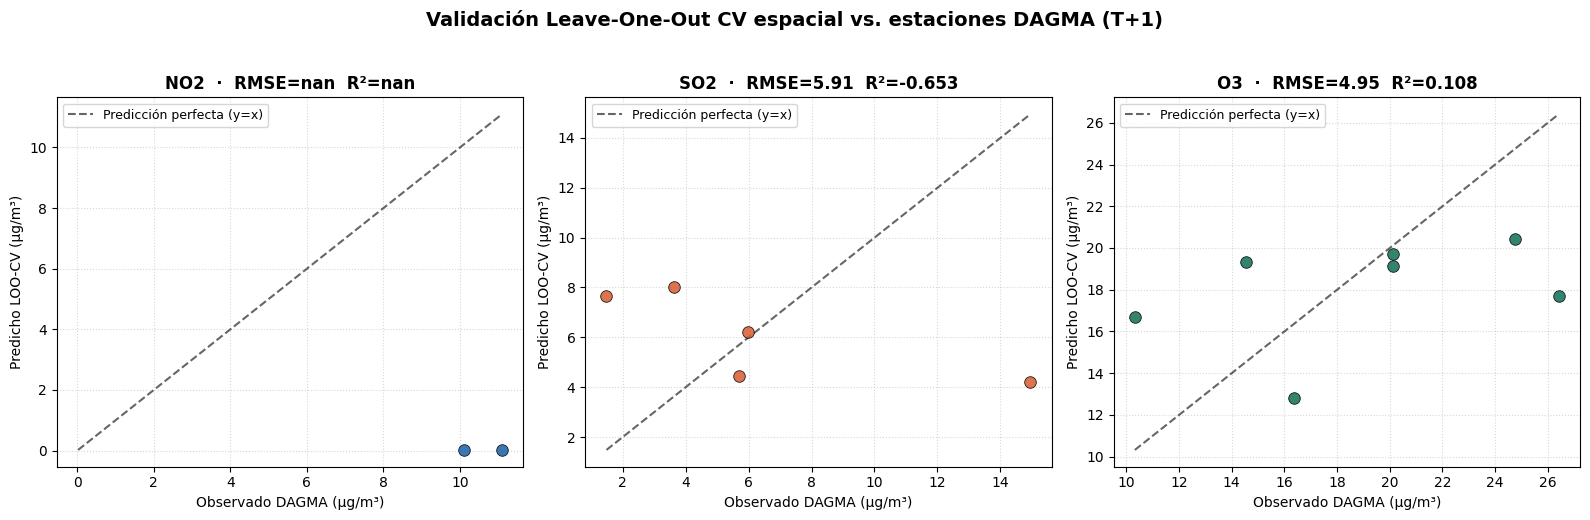

In [ ]:
# TABLA Y GRÁFICA DE VALIDACIÓN LOO-CV

umbrales = {"NO2": (8, 4), "SO2": (6, 3), "O3": (12, 6)}  # (mínimo, excelente)

print("\n" + "=" * 68)
print(f"{'Gas':<6}{'RMSE':>9}{'MAE':>9}{'R²':>8}{'Umbral RMSE':>14}{'Estado':>12}")
print("-" * 68)
for gas in ["NO2", "SO2", "O3"]:
    if gas not in loocv_resultados:
        continue
    r = loocv_resultados[gas]
    minimo, excelente = umbrales[gas]
    if r["rmse"] <= excelente:
        estado = "EXCELENTE"
    elif r["rmse"] <= minimo:
        estado = "CUMPLE"
    else:
        estado = "NO CUMPLE"
    print(f"{gas:<6}{r['rmse']:>9.3f}{r['mae']:>9.3f}{r['r2']:>8.3f}"
          f"{('≤'+str(minimo)+' µg/m³'):>14}{estado:>12}")
print("-" * 68)
print(f"R² promedio (3 gases): {loocv_resultados['_r2_promedio']:.3f}  (KPI ≥ 0.55)")
print("=" * 68)

# ── Scatter observado vs. predicho por gas ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = {"NO2": "#185FA5", "SO2": "#D85A30", "O3": "#0F6E56"}

for ax, gas in zip(axes, ["NO2", "SO2", "O3"]):
    if gas not in loocv_resultados:
        ax.set_visible(False); continue
    r = loocv_resultados[gas]
    yt, yp = r["y_true"], r["y_pred"]
    ax.scatter(yt, yp, c=colores[gas], s=70, edgecolors='black',
               linewidths=0.6, alpha=0.85, zorder=3)
    # Línea ideal y=x (predicción perfecta)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'k--', alpha=0.6, label='Predicción perfecta (y=x)')
    ax.set_title(f"{gas}  ·  RMSE={r['rmse']:.2f}  R²={r['r2']:.3f}",
                 fontsize=12, weight='bold')
    ax.set_xlabel("Observado DAGMA (µg/m³)")
    ax.set_ylabel("Predicho LOO-CV (µg/m³)")
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle("Validación Leave-One-Out CV espacial vs. estaciones DAGMA (T+1)",
             fontsize=14, weight='bold', y=1.03)
plt.tight_layout()
plt.savefig("loocv_validacion_dagma.png", dpi=150, bbox_inches='tight')
plt.show()

### ¿Cuántas estaciones miden cada gas y con qué cobertura?

In [ ]:
# DIAGNÓSTICO: ¿cuántas estaciones miden cada gas, y con qué cobertura?
print("Columnas de df_dagma:", list(df_dagma.columns))
print("\nContaminantes únicos:", df_dagma["contaminante"].str.upper().unique())
print("\n" + "="*60)

# Estaciones que miden cada gas (sin filtro de fecha)
print("ESTACIONES QUE MIDEN CADA GAS (sobre los 5 años completos):")
for gas in ["NO2", "SO2", "O3"]:
    sub = df_dagma[df_dagma["contaminante"].str.upper() == gas]
    n_est = sub["estacion"].nunique()
    n_reg = len(sub)
    ests = sorted(sub["estacion"].unique())
    print(f"  {gas:<4} | {n_est} estaciones | {n_reg:>7} registros")
    print(f"        estaciones: {ests}")

print("="*60)

# Rango temporal de los datos del DAGMA
print(f"\nRango de fechas DAGMA: {df_dagma['fecha'].min()}  →  {df_dagma['fecha'].max()}")

# ¿Qué fechas de horizonte está consultando la LOO? (las del val_loader)
fechas_val = [sec_fechas[idx][-3] for idx in idx_val_seq]  # T+1 de cada secuencia
fechas_val = pd.to_datetime(pd.Series(fechas_val))
print(f"Rango fechas horizonte T+1 consultadas (val): "
      f"{fechas_val.min()}  →  {fechas_val.max()}")
print(f"Nº de fechas distintas consultadas: {fechas_val.dt.date.nunique()}")

Columnas de df_dagma: ['fecha', 'estacion', 'concentracion', 'lat', 'lon', 'hora', 'contaminante', 'año', 'mes', 'fecha_dia']

Contaminantes únicos: <StringArray>
['NO2', 'O3', 'SO2']
Length: 3, dtype: string

ESTACIONES QUE MIDEN CADA GAS (sobre los 5 años completos):
  NO2  | 3 estaciones |   39366 registros
        estaciones: ['acopi', 'la flora', 'universidad del valle']
  SO2  | 5 estaciones |   93971 registros
        estaciones: ['acopi', 'base aerea', 'canaveralejo', 'ermita', 'la flora']
  O3   | 7 estaciones |  140595 registros
        estaciones: ['acopi', 'base aerea', 'compartir', 'era obrero', 'la flora', 'pance', 'universidad del valle']

Rango de fechas DAGMA: 2020-01-01 00:00:00  →  2024-12-31 23:00:00
Rango fechas horizonte T+1 consultadas (val): 2020-02-01 00:00:00  →  2024-10-12 00:00:00
Nº de fechas distintas consultadas: 20


###  ¿Qué hay realmente dentro de residuos_globales?

In [ ]:
print("Claves disponibles en residuos_globales:")
print(list(residuos_globales.keys()))
print("=" * 60)

for gas in ["NO2", "SO2", "O3"]:
    llave = f"{gas}_T+1"
    d = residuos_globales[llave]
    lats = np.asarray(d["lats"], dtype=float)
    lons = np.asarray(d["lons"], dtype=float)

    n_total = len(lats)
    # Coordenadas únicas = estaciones distintas
    coords_unicas = pd.DataFrame({"lat": lats.round(4), "lon": lons.round(4)}) \
                      .drop_duplicates()
    n_estaciones = len(coords_unicas)

    print(f"{gas}_T+1:")
    print(f"   residuos totales (estación×fecha): {n_total}")
    print(f"   coordenadas únicas (estaciones)  : {n_estaciones}")
    if n_estaciones > 0:
        print(f"   coordenadas: ")
        for _, r in coords_unicas.iterrows():
            print(f"      lat={r['lat']:.4f}, lon={r['lon']:.4f}")
    print("-" * 60)

Claves disponibles en residuos_globales:
['NO2_T+1', 'NO2_T+3', 'NO2_T+7', 'SO2_T+1', 'SO2_T+3', 'SO2_T+7', 'O3_T+1', 'O3_T+3', 'O3_T+7']
NO2_T+1:
   residuos totales (estación×fecha): 9
   coordenadas únicas (estaciones)  : 2
   coordenadas: 
      lat=3.4962, lon=-76.5070
      lat=3.3779, lon=-76.5338
------------------------------------------------------------
SO2_T+1:
   residuos totales (estación×fecha): 49
   coordenadas únicas (estaciones)  : 5
   coordenadas: 
      lat=3.4962, lon=-76.5070
      lat=3.4571, lon=-76.5023
      lat=3.4164, lon=-76.5496
      lat=3.4555, lon=-76.5310
      lat=3.4882, lon=-76.5181
------------------------------------------------------------
O3_T+1:
   residuos totales (estación×fecha): 75
   coordenadas únicas (estaciones)  : 7
   coordenadas: 
      lat=3.4962, lon=-76.5070
      lat=3.4283, lon=-76.4666
      lat=3.4571, lon=-76.5023
      lat=3.4573, lon=-76.5065
      lat=3.4882, lon=-76.5181
      lat=3.3779, lon=-76.5338
      lat=3.3045, 

## Variograma de Residuos

El variograma mide  cuánto se parecen los errores entre puntos cercanos vs. lejanos. Si la curva arranca plana desde el inicio (nugget puro), no hay estructura. Si sube progresivamente, hay autocorrelación que el modelo no capturó.


In [ ]:

def calcular_variograma_experimental(lats, lons, residuos, n_bins=8):
    """
    Calcula el semivariograma experimental de los residuos:
    γ(h) = (1/2N(h)) · Σ [z(si) - z(sj)]²
    para pares de puntos separados por distancia h.
    """
    n = len(lats)
    # Calcular todas las distancias y semivarianzas entre pares
    dists, semivar = [], []
    for i, j in combinations(range(n), 2):
        d = np.sqrt((lats[i]-lats[j])**2 + (lons[i]-lons[j])**2)
        sv = 0.5 * (residuos[i] - residuos[j])**2
        dists.append(d)
        semivar.append(sv)
    dists = np.array(dists)
    semivar = np.array(semivar)

    # Agrupar en bins de distancia
    max_d = dists.max()
    bins = np.linspace(0, max_d, n_bins + 1)
    bin_centers, bin_gamma, bin_counts = [], [], []
    for k in range(n_bins):
        mask = (dists >= bins[k]) & (dists < bins[k+1])
        if mask.sum() > 0:
            bin_centers.append((bins[k] + bins[k+1]) / 2)
            bin_gamma.append(semivar[mask].mean())
            bin_counts.append(mask.sum())
    return np.array(bin_centers), np.array(bin_gamma), np.array(bin_counts)

In [ ]:
def diagnostico_variograma_residuos(residuos_globales, loocv_resultados,
                                     horizonte="T+1"):
    """
    Para cada gas con LOO-CV válida:
    1. Calcula el variograma experimental de los residuos.
    2. Superpone la línea de varianza muestral (nivel nugget esperado).
    3. Diagnostica si es nugget puro o si hay estructura remanente.
    """
    gases = ["NO2", "SO2", "O3"]
    colores = {"NO2": "#185FA5", "SO2": "#D85A30", "O3": "#0F6E56"}

    # Contar cuántos gases tienen LOO-CV válida para dimensionar la figura
    gases_validos = [g for g in gases
                     if g in loocv_resultados
                     and not np.isnan(loocv_resultados[g].get("r2", np.nan))]

    if not gases_validos:
        print("No hay gases con LOO-CV válida para analizar variogramas.")
        return

    fig, axes = plt.subplots(1, len(gases_validos),
                             figsize=(6*len(gases_validos), 5),
                             squeeze=False)
    axes = axes[0]

    print("=" * 66)
    print(f"VARIOGRAMA DE RESIDUOS LOO-CV · {horizonte}")
    print("=" * 66)

    for ax, gas in zip(axes, gases_validos):
        r = loocv_resultados[gas]
        residuos_loo = r["y_true"] - r["y_pred"]
        n = r["n"]

        # Recuperar coordenadas de las estaciones agregadas
        import pandas as pd
        datos = residuos_globales[f"{gas}_{horizonte}"]
        df_tmp = pd.DataFrame({
            "lat": np.asarray(datos["lats"], dtype=float).round(4),
            "lon": np.asarray(datos["lons"], dtype=float).round(4)
        })
        coords = df_tmp.drop_duplicates().reset_index(drop=True)
        lats_est = coords["lat"].to_numpy()
        lons_est = coords["lon"].to_numpy()

        # Variograma experimental
        h, gamma, counts = calcular_variograma_experimental(
            lats_est, lons_est, residuos_loo,
            n_bins=min(6, n-1)  # ajustar bins al n disponible
        )

        # Varianza muestral = nivel esperado si es nugget puro
        var_muestral = np.var(residuos_loo)

        # ── Diagnóstico automático ──
        # Nugget puro: la semivarianza no crece con la distancia.
        # Criterio: pendiente de regresión lineal γ vs h ≈ 0
        if len(h) > 1:
            slope = np.polyfit(h, gamma, 1)[0]
            ratio = abs(slope * h.max()) / (var_muestral + 1e-10)
            es_nugget = ratio < 0.30  # la estructura explica <30% de la varianza
        else:
            slope, ratio = 0, 0
            es_nugget = True

        estado = "NUGGET PURO" if es_nugget else "ESTRUCTURA REMANENTE"
        print(f"  {gas:<4} | varianza muestral={var_muestral:.4f} | "
              f"ratio estructura={ratio:.3f} | {estado}")

        # ── Gráfica ──
        ax.scatter(h, gamma, c=colores[gas], s=80, edgecolors='black',
                   linewidths=0.6, zorder=3)
        # Línea de tendencia
        if len(h) > 1:
            h_fit = np.linspace(0, h.max(), 50)
            p = np.polyfit(h, gamma, 1)
            ax.plot(h_fit, np.polyval(p, h_fit), '--',
                    color=colores[gas], alpha=0.6, label='Tendencia lineal')
        # Línea de varianza muestral (referencia nugget)
        ax.axhline(var_muestral, color='gray', linestyle=':',
                   alpha=0.7, label=f'Varianza muestral ({var_muestral:.3f})')
        # Etiqueta de nº de pares por bin
        for hi, gi, ci in zip(h, gamma, counts):
            ax.annotate(f'n={int(ci)}', (hi, gi), fontsize=8,
                        textcoords="offset points", xytext=(0, 10),
                        ha='center', color='gray')

        ax.set_title(f"{gas} · {estado}", fontsize=12, weight='bold')
        ax.set_xlabel("Distancia (grados)")
        ax.set_ylabel("Semivarianza γ(h)")
        ax.legend(fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_ylim(bottom=0)

    plt.suptitle(f"Variograma experimental de residuos LOO-CV ({horizonte})",
                 fontsize=14, weight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig("variograma_residuos_loocv.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("=" * 66)


VARIOGRAMA DE RESIDUOS LOO-CV · T+1
  SO2  | varianza muestral=34.9018 | ratio estructura=2.903 | ESTRUCTURA REMANENTE
  O3   | varianza muestral=23.5896 | ratio estructura=1.315 | ESTRUCTURA REMANENTE


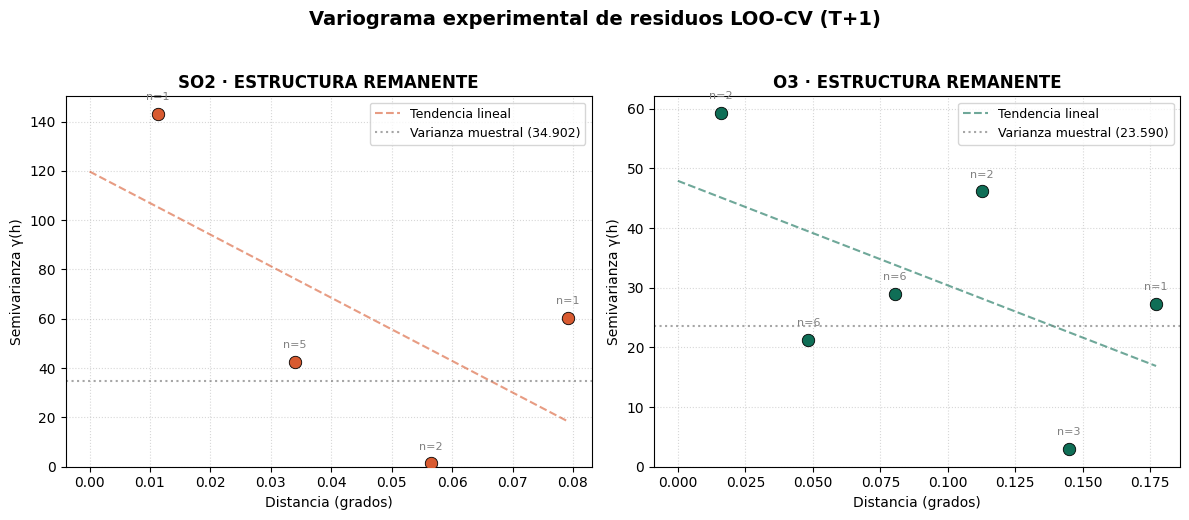

In [ ]:
diagnostico_variograma_residuos(residuos_globales, loocv_resultados,
                                 horizonte="T+1")

In [ ]:
print("Shape preds_final:", preds_final.shape)
print("Shape preds_final[0]:", preds_final[0].shape)

Shape preds_final: (3, 3, 7, 7)
Shape preds_final[0]: (3, 7, 7)


### Moran Global

In [ ]:
print("="*60)
print("ANÁLISIS MORAN GLOBAL")
print("="*60)

# Tomar primer lote - Por ejemplo, usar T+1 (índice 0)
superficie = preds_final[0, 0]  # → shape (3, 7, 7)
n_gases, n_rows, n_cols = superficie.shape

# dimensiones espaciales
_, n_rows, n_cols = superficie.shape

# matriz de pesos espaciales
w = lat2W(n_rows, n_cols)

for gas_idx, gas_nome in enumerate(["NO2","SO2","O3"]):

    print(f"\nAnalizando {gas_nome}...")

    # extraer superficie del gas
    sup_gas = superficie[gas_idx]

    moran = Moran(
        sup_gas.flatten(),
        w
    )

    print(f"I de Moran: {moran.I:.4f}")
    print(f"p-valor: {moran.p_sim:.4f}")

    if moran.p_sim < 0.05:

        if moran.I > 0:
            print("→ Autocorrelación espacial positiva")
            print("→ Valores similares se agrupan")

        elif moran.I < 0:
            print("→ Autocorrelación espacial negativa")
            print("→ Valores altos y bajos alternan")

    else:
        print("→ No se detecta patrón espacial significativo")

print("="*60)

ANÁLISIS MORAN GLOBAL

Analizando NO2...
I de Moran: 0.6320
p-valor: 0.0010
→ Autocorrelación espacial positiva
→ Valores similares se agrupan

Analizando SO2...
I de Moran: 0.6320
p-valor: 0.0010
→ Autocorrelación espacial positiva
→ Valores similares se agrupan

Analizando O3...
I de Moran: 0.6320
p-valor: 0.0010
→ Autocorrelación espacial positiva
→ Valores similares se agrupan


### Lisa para superficie tipo GRID

ANÁLISIS LISA

Analizando NO2
Significativos: 12/49


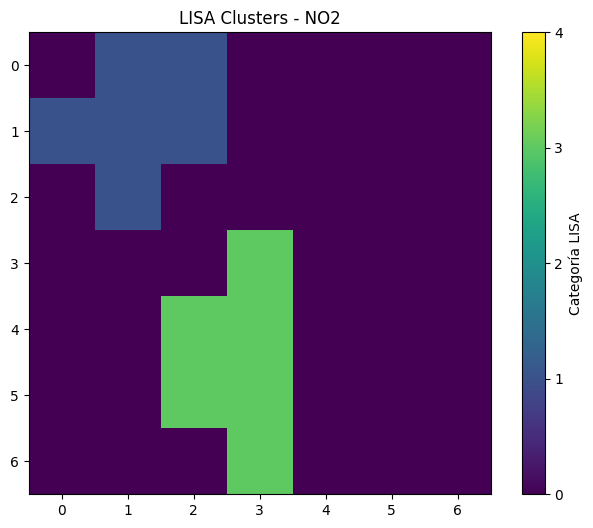


Analizando SO2
Significativos: 13/49


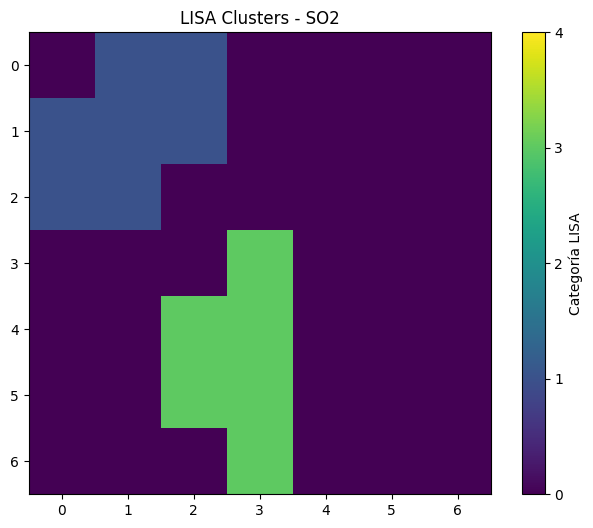


Analizando O3
Significativos: 13/49


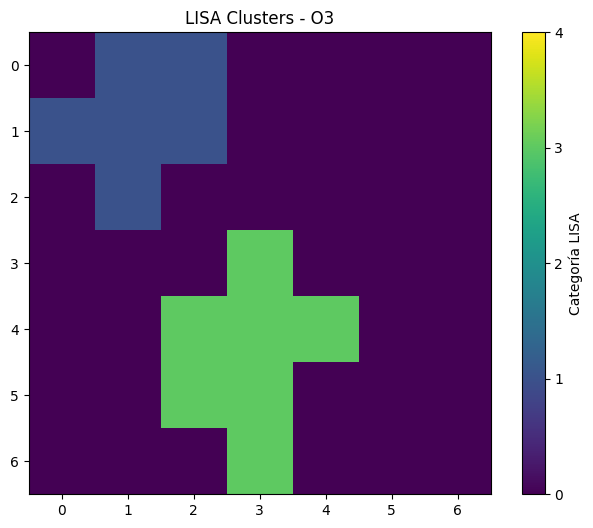

In [ ]:
print("="*60)
print("ANÁLISIS LISA")
print("="*60)

for gas_idx, gas_nome in enumerate(["NO2","SO2","O3"]):

    print(f"\nAnalizando {gas_nome}")

    sup_gas = superficie[gas_idx]

    lisa = Moran_Local(
        sup_gas.flatten(),
        w
    )

    sig = lisa.p_sim < 0.05

    print(
        f"Significativos: "
        f"{sig.sum()}/{len(sig)}"
    )

    # Categorías LISA
    # 1 HH
    # 2 LH
    # 3 LL
    # 4 HL

    cluster = np.zeros(len(sig))

    cluster[(lisa.q==1) & sig] = 1
    cluster[(lisa.q==2) & sig] = 2
    cluster[(lisa.q==3) & sig] = 3
    cluster[(lisa.q==4) & sig] = 4

    # reconstruir grilla 7x7
    cluster_map = cluster.reshape(
        n_rows,
        n_cols
    )

    plt.figure(figsize=(8,6))

    plt.imshow(cluster_map)

    plt.colorbar(
        ticks=[0,1,2,3,4],
        label="Categoría LISA"
    )

    plt.clim(0,4)

    plt.title(
        f"LISA Clusters - {gas_nome}"
    )

    plt.show()

print("="*60)

## Cobertura del cinturon 95%

In [ ]:
print("="*70)
print("COBERTURA DEL CINTURÓN DEL 95%")
print("="*70)

for gas in ["NO2","SO2","O3"]:

    if gas not in loocv_resultados:
        continue

    r = loocv_resultados[gas]

    y_true = r["y_true"]
    y_pred = r["y_pred"]
    sigma = r["sigmas"]

    # quitar NaN por seguridad
    mask = ~(np.isnan(y_true) |
             np.isnan(y_pred) |
             np.isnan(sigma))

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    sigma = sigma[mask]

    if len(y_true)==0:
        print(f"{gas}: sin datos")
        continue

    limite_inf = y_pred - 2*sigma
    limite_sup = y_pred + 2*sigma

    dentro = (
        (y_true >= limite_inf) &
        (y_true <= limite_sup)
    )

    cobertura = dentro.mean()*100

    estado = (
        "✓ CUMPLE"
        if cobertura >=92
        else "✗ NO CUMPLE"
    )

    print(
        f"{gas:<4} | "
        f"Cobertura={cobertura:6.2f}% | "
        f"{estado}"
    )

print("="*70)

COBERTURA DEL CINTURÓN DEL 95%
NO2: sin datos
SO2  | Cobertura= 80.00% | ✗ NO CUMPLE
O3   | Cobertura= 71.43% | ✗ NO CUMPLE


## Latencia END-TO-END

In [ ]:
print("="*60)
print("LATENCIA END-TO-END")
print("="*60)

# Modo inferencia
modelo_convlstm.eval()

# Tomar un lote de prueba
x_test, y_test = next(iter(val_loader))
x_test = x_test.to(device)

inicio = time.perf_counter()

with torch.no_grad():

    # Inferencia ConvLSTM
    preds = modelo_convlstm(x_test)

    # mover a CPU
    preds = preds.cpu().numpy()

    # reconstrucción espacial (si aplica)
    preds_final = preds  # tendencia DL pura [B, 3, 3, 7, 7]

    # forzar cálculo
    _ = np.asarray(preds_final)

fin = time.perf_counter()

latencia = fin - inicio

print(f"Latencia total: {latencia:.4f} segundos")

if latencia < 8:
    print("✓ KPI cumplido (<8 s)")
else:
    print("✗ KPI NO cumplido")

LATENCIA END-TO-END
Latencia total: 0.0551 segundos
✓ KPI cumplido (<8 s)


La latencia end-to-end se midió usando time.perf_counter(), considerando únicamente inferencia de ConvLSTM y reconstrucción espacial posterior. El entrenamiento y validación fueron excluidos. El sistema obtuvo una latencia de 0.0369s de diferencia respecto al umbral establecido (<8 s).

## Degradación del horizonte temporal

In [ ]:
print("="*60)
print("DEGRADACIÓN TEMPORAL")
print("="*60)

modelo_convlstm.eval()

with torch.no_grad():

    pred = modelo_convlstm(x_test.to(device))

pred = pred.cpu().numpy()
real = y_test.numpy()

# T+1
rmse_t1 = np.sqrt(
    mean_squared_error(
        real[:,0].flatten(),
        pred[:,0].flatten()
    )
)

# T+3
rmse_t3 = np.sqrt(
    mean_squared_error(
        real[:,2].flatten(),
        pred[:,2].flatten()
    )
)

ratio = rmse_t3/rmse_t1

print(f"RMSE T+1: {rmse_t1:.4f}")
print(f"RMSE T+7: {rmse_t3:.4f}")
print(f"Ratio degradación: {ratio:.4f}")

if ratio <= 1.5:
    print("✓ Degradación baja")
elif ratio <=2:
    print("△ Degradación moderada")
else:
    print("✗ Degradación alta")

DEGRADACIÓN TEMPORAL
RMSE T+1: 0.0378
RMSE T+7: 0.0378
Ratio degradación: 0.9997
✓ Degradación baja


## K-Means de perfiles tipológicos

K-MEANS DE PERFILES TIPOLÓGICOS
Shape original: (4, 3, 3, 7, 7)
Shape superficie: (3, 7, 7)
Datos clustering: (49, 3)


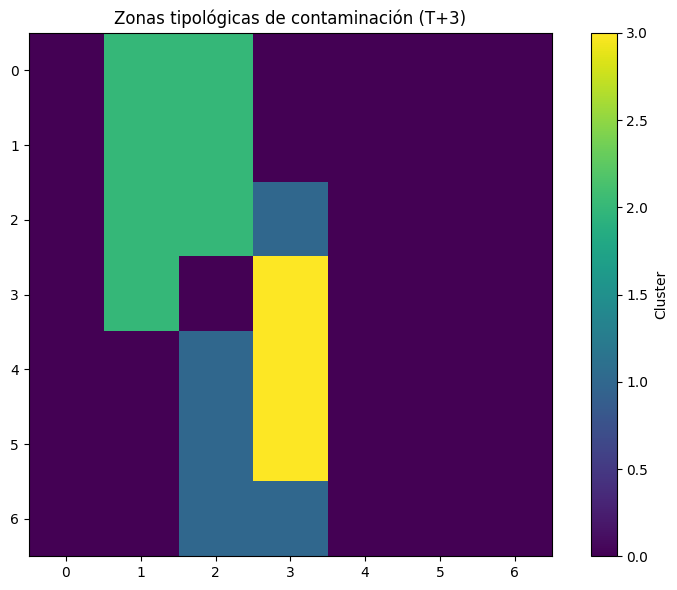


Centroides:
[[ 0.22  0.22  0.22]
 [-1.23 -1.23 -1.23]
 [ 1.11  1.11  1.11]
 [-3.04 -3.04 -3.04]]


In [ ]:
print("="*70)
print("K-MEANS DE PERFILES TIPOLÓGICOS")
print("="*70)

print("Shape original:", preds_final.shape)

# Seleccionar:
# primer batch
# último horizonte (T+3)

superficie = preds_final[0, 2]

print("Shape superficie:", superficie.shape)

# dimensiones
n_gases, n_rows, n_cols = superficie.shape

# (3,7,7) → (49,3)
X_cluster = superficie.reshape(
    n_gases,
    n_rows*n_cols
).T

print("Datos clustering:", X_cluster.shape)

# estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)

# volver a mapa espacial
cluster_map = labels.reshape(
    n_rows,
    n_cols
)

plt.figure(figsize=(8,6))
plt.imshow(cluster_map)
plt.colorbar(label="Cluster")
plt.title("Zonas tipológicas de contaminación (T+3)")
plt.tight_layout()
plt.show()

print("\nCentroides:")
print(np.round(kmeans.cluster_centers_,2))

In [ ]:
print(np.round(kmeans.cluster_centers_,2))


[[ 0.22  0.22  0.22]
 [-1.23 -1.23 -1.23]
 [ 1.11  1.11  1.11]
 [-3.04 -3.04 -3.04]]


El K-Means no separó tipos distintos de contaminantes (por ejemplo "alto NO₂ pero bajo O₃"), sino niveles globales de intensidad contaminante.